<div style="background-color: #5397cbff ; padding: 20px; border-radius: 10px;">

<h1 style="color: black; text-align: center;">
    ML Project :  F1 lap time prediction
</h1>

<h3 style="color: black; text-align: center;">
    Notebook Pre-processing
</h3>

<h5 style="color: black; text-align: center;">
    Elisabth Cognet, Nour El Khalili, Chatron Emilie -- MMN2
</h5>

</div>

Objectives of this notebook :
1) EDA
- Load raw data
- Do a pre-treatment to generate a unique merged dataset
- Explore our data (distributions and correlations)
- Conclusion : Ideas for our pre-processing
2) Pre-processing
- 

In [56]:
#Librairies

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns
from scipy.stats import chi2_contingency



## Load raw data 

In [57]:
#Load datasets
circuits = pd.read_csv("./data/raw/circuits.csv")
constructor_results = pd.read_csv("./data/raw/constructor_results.csv")
constructor_standings = pd.read_csv("./data/raw/constructor_standings.csv")
constructors = pd.read_csv("./data/raw/constructors.csv")
driver_standings = pd.read_csv("./data/raw/driver_standings.csv")
drivers = pd.read_csv("./data/raw/drivers.csv")
lap_times = pd.read_csv("./data/raw/lap_times.csv")
pit_stops = pd.read_csv("./data/raw/pit_stops.csv")
qualifying = pd.read_csv("./data/raw/qualifying.csv")
races = pd.read_csv("./data/raw/races.csv")
results = pd.read_csv("./data/raw/results.csv")
seasons = pd.read_csv("./data/raw/seasons.csv")
sprint_results = pd.read_csv("./data/raw/sprint_results.csv")
status = pd.read_csv("./data/raw/status.csv")

datasets = {
    "circuits": circuits,
    "constructor_results": constructor_results,
    "constructor_standings": constructor_standings,
    "constructors": constructors,
    "driver_standings": driver_standings,
    "drivers": drivers,
    "lap_times": lap_times,
    "pit_stops": pit_stops,
    "qualifying": qualifying,
    "races": races,
    "results": results,
    "seasons": seasons,
    "sprint_results": sprint_results,
    "status": status
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} lignes, {df.shape[1]} colonnes")

# Optionnel : afficher les 3 premières lignes de chaque fichier
for name, df in datasets.items():
    print(f"\n=== {name} ===")
    display(df.head(3))



circuits: 77 lignes, 11 colonnes
constructor_results: 12625 lignes, 5 colonnes
constructor_standings: 13391 lignes, 7 colonnes
constructors: 212 lignes, 5 colonnes
driver_standings: 34863 lignes, 7 colonnes
drivers: 861 lignes, 9 colonnes
lap_times: 589081 lignes, 6 colonnes
pit_stops: 11371 lignes, 7 colonnes
qualifying: 10494 lignes, 9 colonnes
races: 1125 lignes, 18 colonnes
results: 26759 lignes, 18 colonnes
seasons: 75 lignes, 2 colonnes
sprint_results: 360 lignes, 16 colonnes
status: 139 lignes, 2 colonnes

=== circuits ===


,circuitId,circuitRef,name,location,country,lat,lng,alt,url,length (km),Turns
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.9680,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...,5.278,16
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.7380,18,http://en.wikipedia.org/wiki/Sepang_Internatio...,5.543,15
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.5106,7,http://en.wikipedia.org/wiki/Bahrain_Internati...,5.412,15



=== constructor_results ===


,constructorResultsId,raceId,constructorId,points,status
0,1,18,1,14.0,\N
1,2,18,2,8.0,\N
2,3,18,3,9.0,\N



=== constructor_standings ===


...

,year,url
0,2009,http://en.wikipedia.org/wiki/2009_Formula_One_...
1,2008,http://en.wikipedia.org/wiki/2008_Formula_One_...
2,2007,http://en.wikipedia.org/wiki/2007_Formula_One_...



=== sprint_results ===


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,fastestLapTime,statusId
0,1,1061,830,9,33,2,1,1,1,3,17,25:38.426,1538426,14,1:30.013,1
1,2,1061,1,131,44,1,2,2,2,2,17,+1.430,1539856,17,1:29.937,1
2,3,1061,822,131,77,3,3,3,3,1,17,+7.502,1545928,17,1:29.958,1



=== status ===


,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident


# Pre-treatment

## Missing values

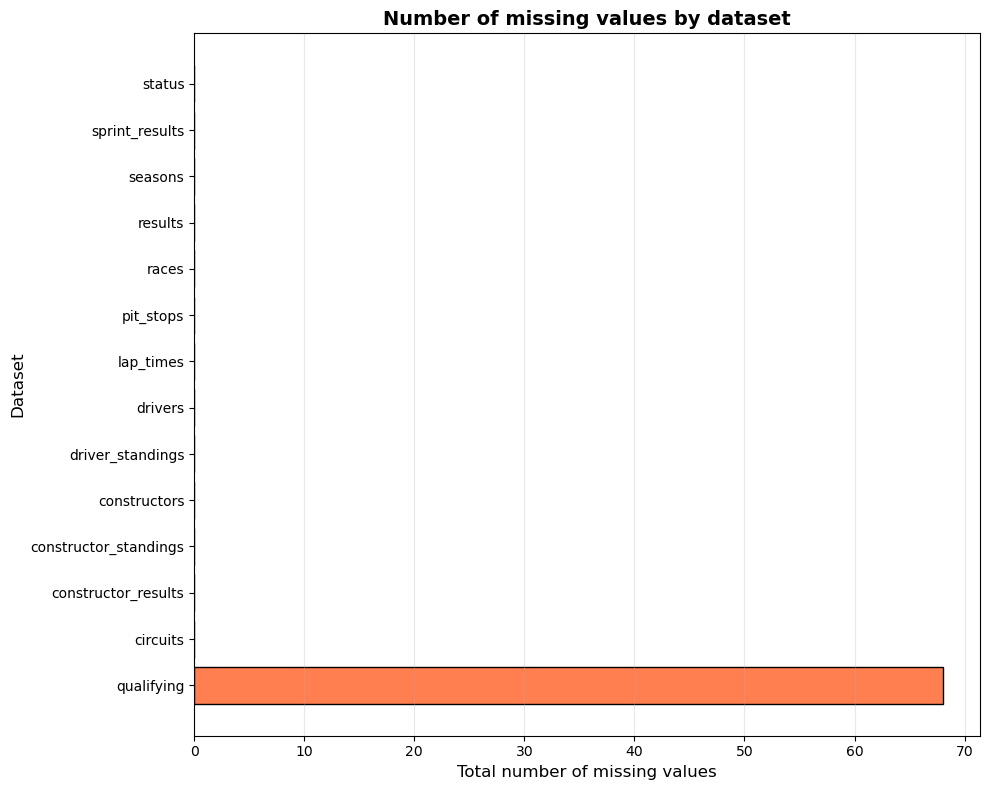

qualifying: 68 missing values (0.07%)
circuits: 0 missing values (0.00%)
constructor_results: 0 missing values (0.00%)
constructor_standings: 0 missing values (0.00%)
constructors: 0 missing values (0.00%)
driver_standings: 0 missing values (0.00%)
drivers: 0 missing values (0.00%)
lap_times: 0 missing values (0.00%)
pit_stops: 0 missing values (0.00%)
races: 0 missing values (0.00%)
results: 0 missing values (0.00%)
seasons: 0 missing values (0.00%)
sprint_results: 0 missing values (0.00%)
status: 0 missing values (0.00%)


In [58]:
missing_counts = {}
for name, df in datasets.items():
    missing_counts[name] = df.isnull().sum().sum()

plt.figure(figsize=(10, 8))
datasets_sorted = dict(sorted(missing_counts.items(), key=lambda x: x[1], reverse=True))
plt.barh(list(datasets_sorted.keys()), list(datasets_sorted.values()), color='coral', edgecolor='black')
plt.xlabel('Total number of missing values', fontsize=12)
plt.ylabel('Dataset', fontsize=12)
plt.title('Number of missing values by dataset', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

for name, count in sorted(missing_counts.items(), key=lambda x: x[1], reverse=True):
    total_cells = datasets[name].shape[0] * datasets[name].shape[1]
    percentage = (count / total_cells) * 100 if total_cells > 0 else 0
    print(f"{name}: {count} missing values ({percentage:.2f}%)")


As we can see, there is very few missing values so we don't have to worry too much about missing values.

## Keeping useful columns only

We will keep only relevant columns and datasets for our subject

"Predicting best lap times for each driver for a fixed circuit and year"

We thought the following datasets were not useful for the subject :

*   constructor_results
*   constructor_standings
*   driver_standings
*   sprint_results
*   status
*   seasons
*   pit_stops
*   qualifying

For the other datasets, we also kept only the columns we thought relevant for our project.

In [59]:
circuits=circuits[['circuitId','circuitRef','location','length (km)','Turns ']]
races=races[['raceId','year','circuitId','date']]
drivers=drivers[['driverId','driverRef','nationality']]
constructors=constructors[['constructorId','constructorRef','nationality']]
lap_times=lap_times[['raceId','driverId','lap','milliseconds']]
results=results[['raceId','driverId','constructorId','grid','position','points','laps','statusId']]


We reduced the number of columns from 102 to 21, making analysis easier while keeping key informations.

## Merging datasets


To have a unique dataset we merge the previous selected ones on the different IDs.

In [60]:
merged = lap_times.merge(results, on=['raceId', 'driverId'], how='left')
merged = merged.merge(races, on='raceId', how='left')
merged = merged.merge(circuits, on='circuitId', how='left')
merged = merged.merge(drivers, on='driverId', how='left')
merged = merged.merge(constructors, on='constructorId', how='left', suffixes=('_driver', '_constructor'))
df=merged
print(df.shape)
print(df.info())
#print(df.head())

(589081, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589081 entries, 0 to 589080
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   raceId                   589081 non-null  int64  
 1   driverId                 589081 non-null  int64  
 2   lap                      589081 non-null  int64  
 3   milliseconds             589081 non-null  int64  
 4   constructorId            589081 non-null  int64  
 5   grid                     589081 non-null  int64  
 6   position                 589081 non-null  object 
 7   points                   589081 non-null  float64
 8   laps                     589081 non-null  int64  
 9   statusId                 589081 non-null  int64  
 10  year                     589081 non-null  int64  
 11  circuitId                589081 non-null  int64  
 12  date                     589081 non-null  object 
 13  circuitRef               589081 non-null  obje

We have 11 quantitatives and 8 qualitatives columns.

In [61]:
merged.to_csv('data/processed/merged_data.csv', index=False)

print(f"Données sauvegardées dans data/processed/merged_data.csv")

Données sauvegardées dans data/processed/merged_data.csv


# EDA

## Univariate analysis and statistics

### Drivers

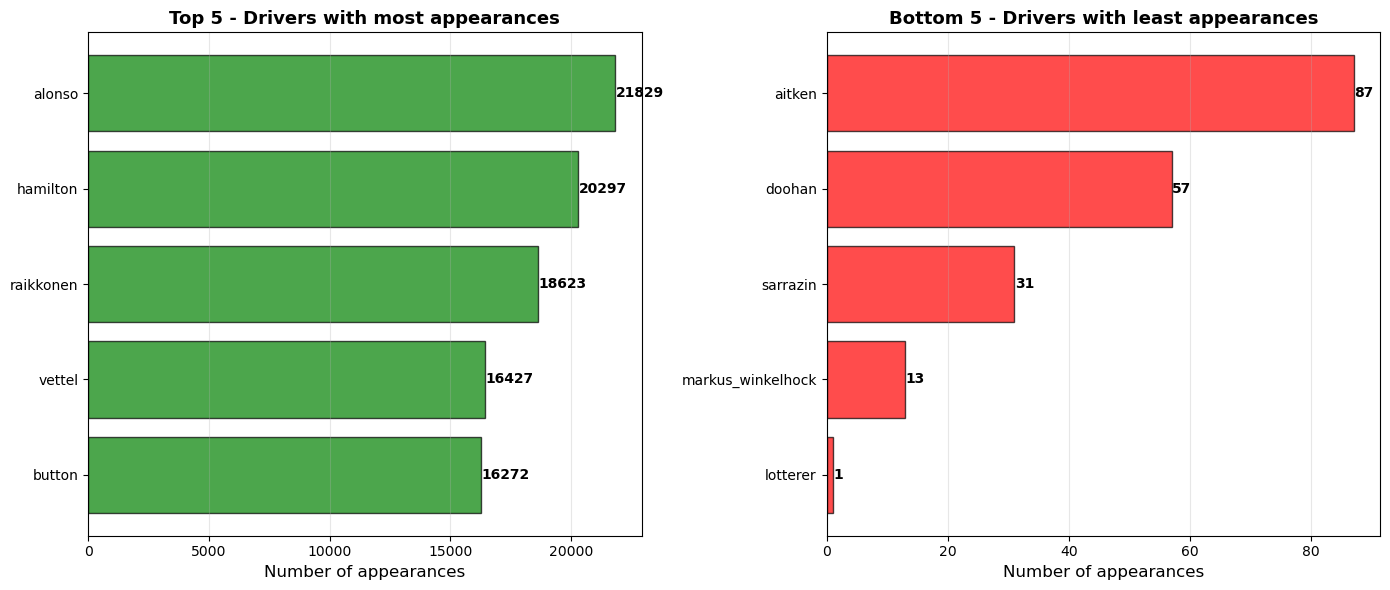

There are 143 different drivers in the dataset.


In [62]:
driver_counts = merged['driverRef'].value_counts()

top_5 = driver_counts.head(5)
bottom_5 = driver_counts.tail(5)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))


bars1 = ax1.barh(range(len(top_5)), top_5.values[::-1], color='green', edgecolor='black', alpha=0.7)
ax1.set_yticks(range(len(top_5)))
ax1.set_yticklabels(top_5.index[::-1])
ax1.set_xlabel('Number of appearances', fontsize=12)
ax1.set_title('Top 5 - Drivers with most appearances', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)


for i, count in enumerate(top_5.values[::-1]):
    ax1.text(count + 5, i, str(count), ha='left', va='center', fontsize=10, fontweight='bold')

bars2 = ax2.barh(range(len(bottom_5)), bottom_5.values[::-1], color='red', edgecolor='black', alpha=0.7)
ax2.set_yticks(range(len(bottom_5)))
ax2.set_yticklabels(bottom_5.index[::-1])
ax2.set_xlabel('Number of appearances', fontsize=12)
ax2.set_title('Bottom 5 - Drivers with least appearances', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)


for i, count in enumerate(bottom_5.values[::-1]):
    ax2.text(count + 0.05, i, str(count), ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"There are {driver_counts.count()} different drivers in the dataset.")




In our dataset you can find 143 different drivers. We ranked them by the number of laps they did. Fun fact Lotterer only did one lap in his entire career because he had a problem and couln't finish his first ever lap. He surprisingly stop F1 after this incident. https://en.wikipedia.org/wiki/Andr%C3%A9_Lotterer

### Races

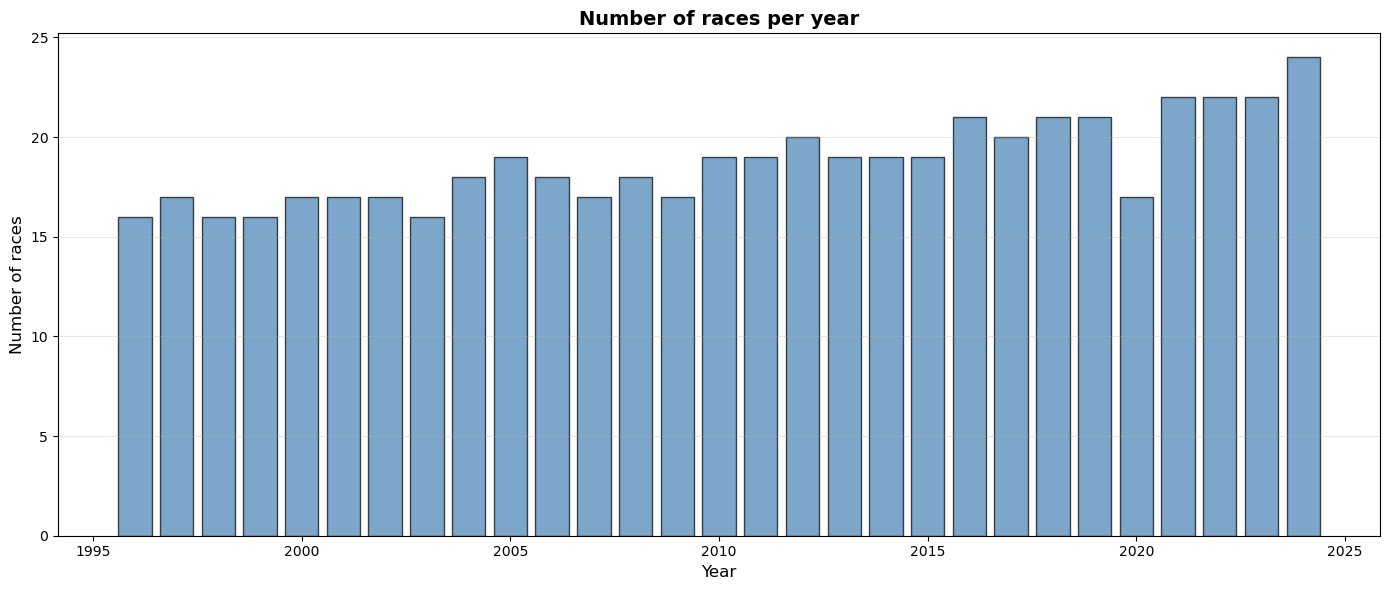

There are 544 different races.


In [63]:
races_per_year = merged.groupby('year')['raceId'].nunique().reset_index(name='nb_races')


plt.figure(figsize=(14, 6))
plt.bar(races_per_year['year'], races_per_year['nb_races'], color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of races', fontsize=12)
plt.title('Number of races per year', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"There are 544 different races.")

544 different courses since 1996. We can see that at first there was 16 races by year and with time, they changed some circuits. Globally, the number of circuits per year increased and nowadays there is 24 races by year.

### Circuits

In [64]:
nb_circuits = merged['circuitId'].nunique()
print(f"There are {nb_circuits} different circuits in the dataset.")
courses_par_circuit = (
    df[['raceId', 'circuitId']]
    .drop_duplicates()
    .groupby('circuitId')
    .size()
    .reset_index(name='nb_courses')
    .sort_values(by='nb_courses', ascending=False)
)
courses_par_circuit = courses_par_circuit.merge(circuits, on='circuitId', how='left')
print("\n Top 3 circuits with most races")
courses_par_circuit[['circuitRef', 'nb_courses']].head(3)


There are 41 different circuits in the dataset.

 Top 3 circuits with most races


,circuitRef,nb_courses
0,silverstone,30
1,catalunya,29
2,hungaroring,29


In [65]:
print("\n Top 3 circuits with less races")
courses_par_circuit[['circuitRef', 'nb_courses']].tail(3)


 Top 3 circuits with less races


,circuitRef,nb_courses
38,jerez,1
39,estoril,1
40,mugello,1


41 differents circuits since 1996. The only circuit that is here since 1996 is Silverstone. Some other circuits are quite old too but there is also some that were run once. We have to know that depending on the circuit we will have more or less informations.

### Constructors

In [66]:
constructor_counts = merged.groupby('constructorRef')['raceId'].nunique().reset_index(name='number_of_races')
constructor_counts = constructor_counts.merge(
    merged[['constructorRef', 'nationality_constructor']].drop_duplicates(),
    on='constructorRef',
    how='left'
)
constructor_counts = constructor_counts.sort_values(by='number_of_races', ascending=False)
constructor_counts.head(10)

,constructorRef,number_of_races,nationality_constructor
10,ferrari,543,Italian
42,williams,543,British
24,mclaren,542,British
31,red_bull,392,Austrian
33,sauber,365,Swiss
25,mercedes,304,German
32,renault,277,French
38,toro_rosso,267,Italian
12,force_india,212,Indian
14,haas,189,American


We can see that over the 544 races of our dataset, some constructors like Ferrari participated to almost all races over the past 20 years.

### Position

We do a change of type here to ba able to see correlations better in the multivariate analysis part. Since this change does not cause any data leakage I think we can do it in EDA part.

In [67]:
merged['position'] = pd.to_numeric(merged['position'], errors='coerce').astype('Int64')
#print("dtype position :", merged['position'].dtype)
print(f"Range: {merged['position'].min()} - {merged['position'].max()}")

Range: 1 - 24


On peut voir qu'il y a bien 24 pilotes par course. La position d'arrivée est donc naturellement entre 1 et 24.

### Lap & Laps

Column "lap" is the column corresponding to number of the lap the driver currently is. Example : lap 4 of the course for a given driver and race. For more clarity, we will rename it "current_lap".

Now we create our target variable "fastest_lap_time" which is the faster lap time for a given pilot, circuit and year (so given pilot and race).

In [68]:

print(merged['lap'].describe())

count    589081.000000
mean         30.018104
std          18.407126
min           1.000000
25%          14.000000
50%          29.000000
75%          44.000000
max          87.000000
Name: lap, dtype: float64


Almost the same as 'lap', 'laps' is the total number of laps completed at the end of a race by a driver. As we said in the Lap section, some drivers do not finish the race so this can differ between drivers on a same race. We will also rename it in "total_laps"

In [69]:
print(merged['laps'].describe())

count    589081.000000
mean         59.021839
std          12.095074
min           0.000000
25%          53.000000
50%          58.000000
75%          69.000000
max          87.000000
Name: laps, dtype: float64


We can see that the mean number of lap completed in a race is 59. This variable ranges from 0 to 87 laps (Monaco). If a driver is out, the remaining laps are not in our dataset so for a same race, the number of laps may differ depending on the driver. This explain why the minimum total number of laps is 0, maybe a driver had a problem with the car before the race and couldn't start.

### Length

In [70]:
print(merged['length (km)'].describe())

count    589081.000000
mean         41.618493
std         474.032637
min           3.337000
25%           4.361000
50%           4.940000
75%           5.543000
max        6174.000000
Name: length (km), dtype: float64


We can see that one value was badly inputed, it seems like the value is in meter and not kilometer so we will change it here by dividing the value by 1000 when it's this value.

In [71]:
merged.loc[merged["length (km)"] == 6174, "length (km)"] = merged["length (km)"] / 1000

# We do this change here in EDA to fix an error in dataset
# I think it's okay do change dataset here because it's a small fix for an obvious error
print(merged['length (km)'].describe())

count    589081.000000
mean          4.983084
std           0.792213
min           3.337000
25%           4.361000
50%           4.940000
75%           5.543000
max           7.004000
Name: length (km), dtype: float64


Now we have coherent values, on average, tracks are 5km long with a standard deviation of almost 0.8. That shows that circuit length can be quite different, going from 3.3 to 7km.

### Turns

There was a space after the name of the column so we detete it and modify the name to put a clearer one.

In [72]:
print(merged['Turns '].describe())

count    589081.000000
mean         15.899696
std           2.820706
min          10.000000
25%          14.000000
50%          16.000000
75%          18.000000
max          27.000000
Name: Turns , dtype: float64


Here, we see that we generally have around 16 turns on our tracks but it varies a lot. It surelly depends on the length of the track but we will see that with the correlation matrix.

### Milliseconds & creation of Target Variable

This is the variable we will use to create our target variable. We will convert rename it in 'lapSeconds' and convert it in seconds to make it easier to read.


In [73]:
merged["lapSeconds"] = merged["milliseconds"] / 1000
merged = merged.drop(columns=['milliseconds'])

In [74]:
print(merged['lapSeconds'].describe())

count    589081.000000
mean         95.799445
std          76.399730
min          55.404000
25%          82.041000
50%          90.608000
75%         101.930000
max        7507.547000
Name: lapSeconds, dtype: float64


We can see that the mean time for a lap is approximately 95.8s but the standard deviation is quite high (76.4s). This is normal because these statistics are done for all circuits and years mixed and we know that all circuits have different lengths.

Now we create our target variable "fastest_lap_time" which is the faster lap time for a given pilot, circuit and year (so given pilot and race).

In [75]:
merged['fastestLapTime'] = (merged.groupby(['raceId', 'driverId'])['lapSeconds'].transform('min'))

### Evolution of fastest lap time over year

We wanted to see how the speed of cars in F1 evolved over time. For this, we had to study the global best lap time (all driver) for a specified circuit. We first did it with Silverstone circuit because it's the oldest in our dataset but the layout of this circuit changed a lot in 30 years so the results were not very interesting. We chose Albert Park circuit because he is old and didn't change in the last few years.

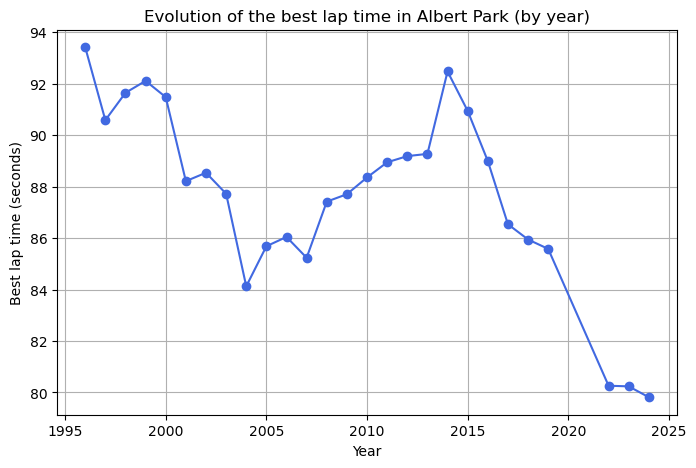

In [76]:
albert_park = merged[merged['circuitRef'].str.contains("albert_park", case=False, na=False)]


evolution = (
    albert_park.groupby('year')['fastestLapTime']
    .min()
    .reset_index()
    .sort_values('year')
)
plt.figure(figsize=(8,5))
plt.plot(evolution['year'], evolution['fastestLapTime'], marker='o', linestyle='-', color='royalblue')
plt.title("Evolution of the best lap time in Albert Park (by year)")
plt.xlabel("Year")
plt.ylabel("Best lap time (seconds)")
plt.grid(True)
plt.show()

On this diagramm, we can see that the best lap time globally decreased since 1995. Independently of the layout changes and the weather that can affect the lap times, we can see that cars are getting faster and faster and we have to adapt our model to these technological changes.

We looked online and saw that one major change in F1 field is the introduction of hybrid V6 turbo engines in 2014.
These engines are far more powerful than the precedents and new rules were also added that year. We can see it on this graph and we wanted to see if this change was also visible on other circuit :

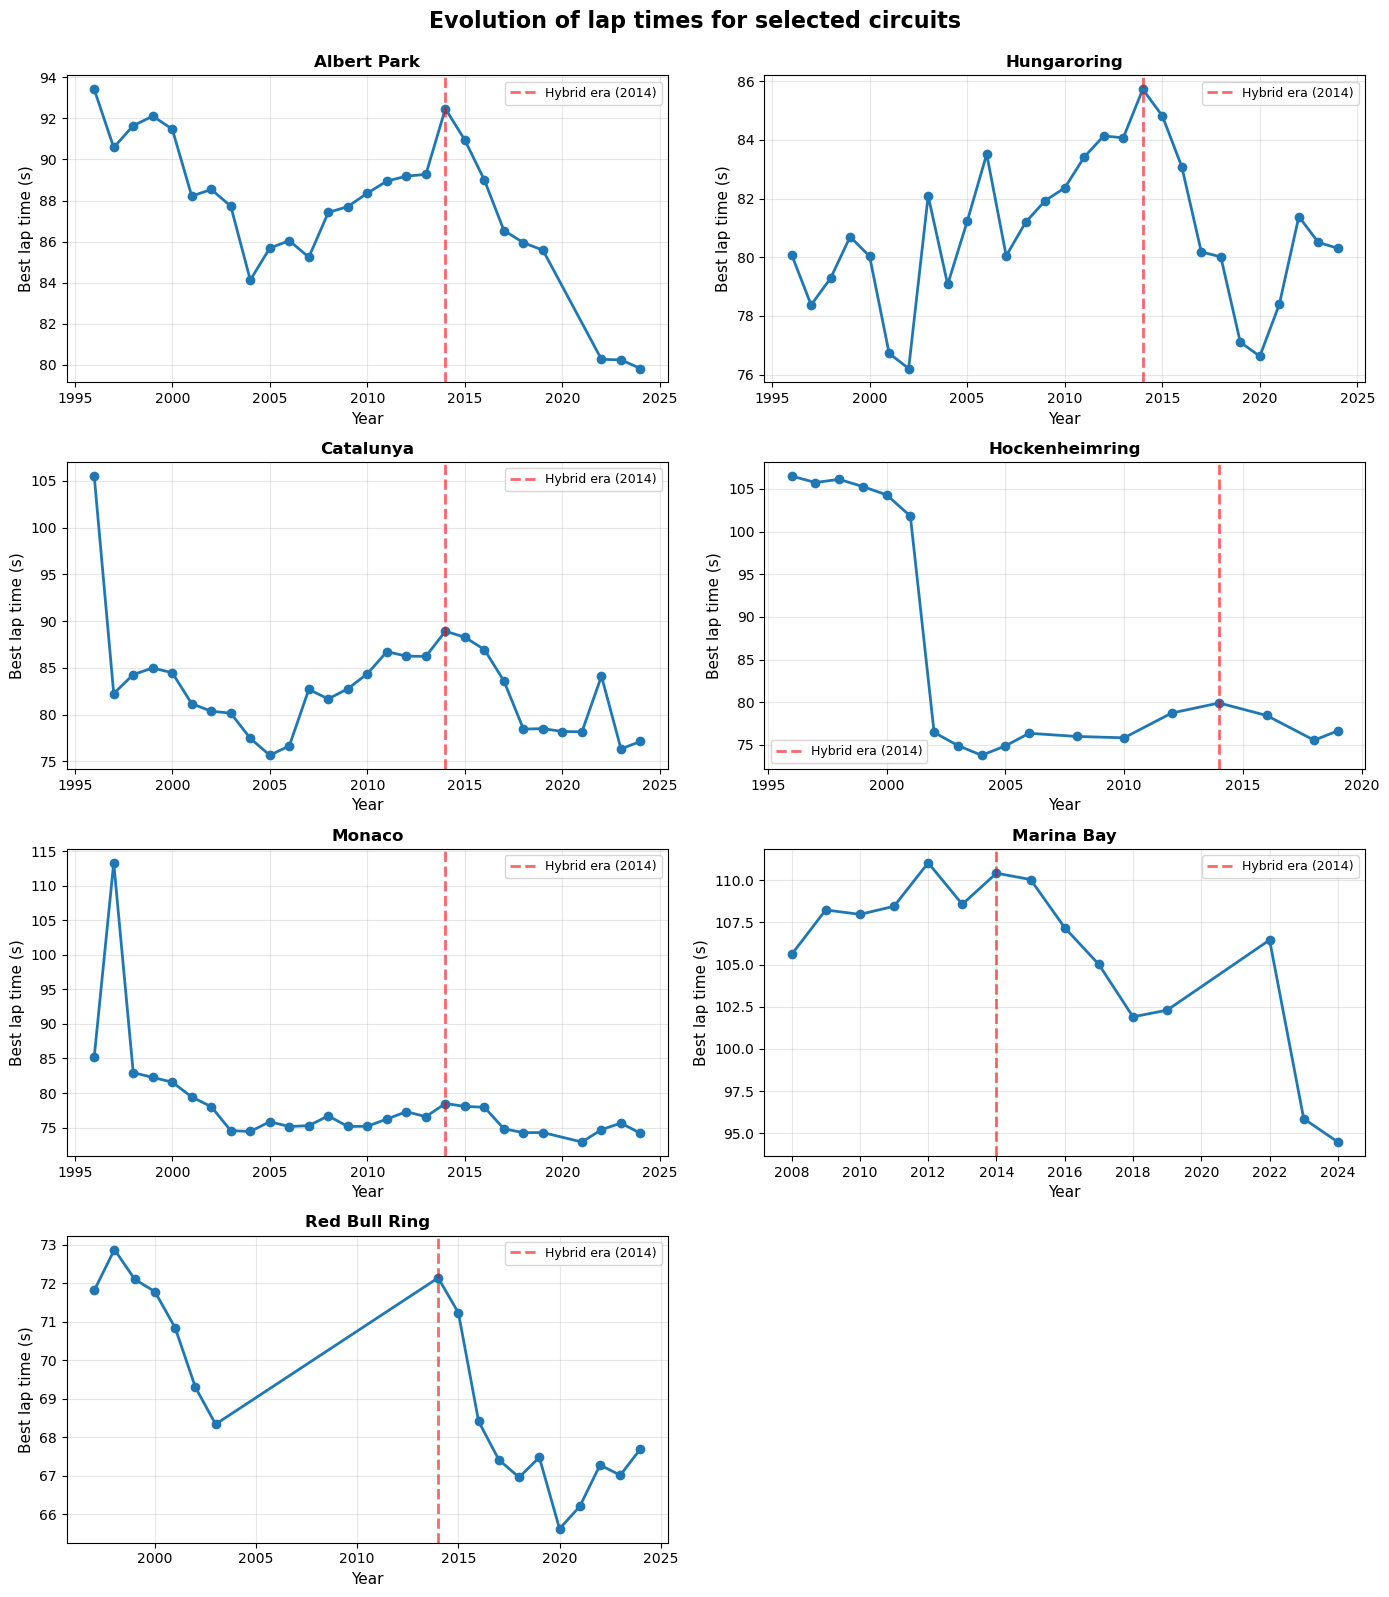

In [77]:
selected_circuits = ['albert_park', 'hungaroring', 'catalunya', 'hockenheimring', 
                    'monaco', 'marina_bay', 'red_bull_ring']


fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for idx, circuit in enumerate(selected_circuits):
    circuit_data = merged[merged['circuitRef'] == circuit].copy()
    evolution = circuit_data.groupby('year')['fastestLapTime'].min().reset_index()
    
    ax = axes[idx]
    ax.plot(evolution['year'], evolution['fastestLapTime'], marker='o', linewidth=2, markersize=6)
    ax.set_title(f"{circuit.replace('_', ' ').title()}", fontweight='bold', fontsize=12)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Best lap time (s)', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=2014, color='red', linestyle='--', alpha=0.6, linewidth=2, label='Hybrid era (2014)')
    ax.legend(fontsize=9)

axes[-1].axis('off')

plt.suptitle('Evolution of lap times for selected circuits', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

We can see that this change is visible on other circuits so this not an isolated phenomena. 
Other major changes occured since 2014 but in order to keep a decent amount of data, we will limit our study to 2014-2024 to have a 10-year long dataset. Also, we will do our predictions for 2024-2025 drivers and circuits so 15-year-old data will not be very useful. 

We will see in at the end of the EDA that we will train our models on both datasets (one with all data and one with data from 2014).

## Multivariate analysis

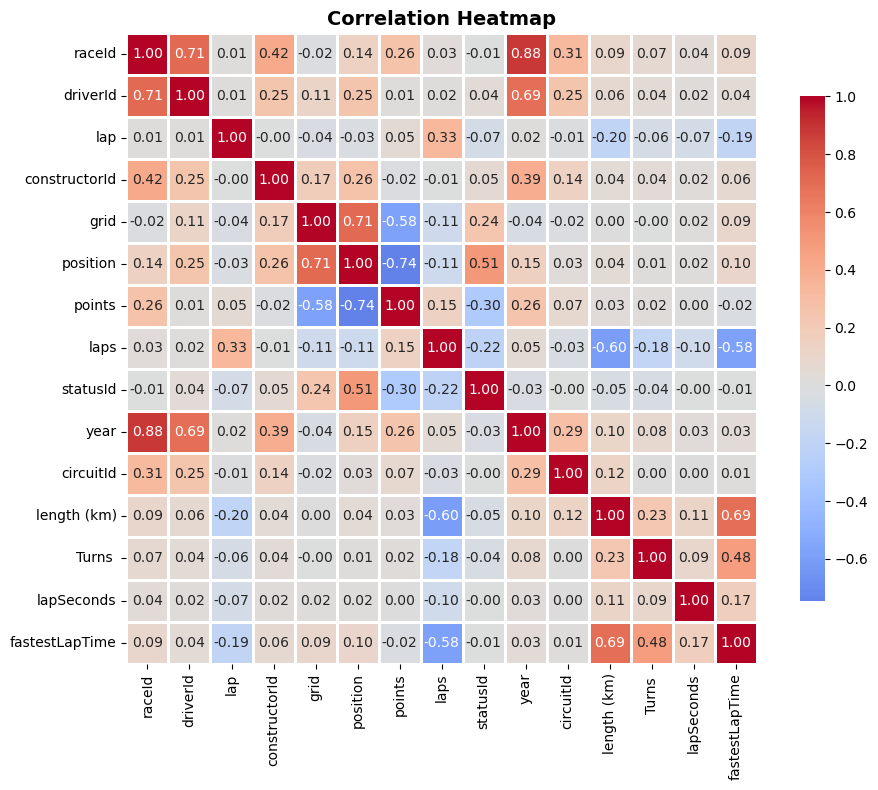

In [78]:
numerical_cols = merged.select_dtypes(include=['int64', 'int32', 'float64', 'float32']).columns.tolist()

plt.figure(figsize=(10, 8))
correlation_matrix = merged[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Because most of our numerical columns are Ids, we have strong correlations that are not very interesting. 
For example, 'raceId', 'driverId' or 'constructorId' are strongly correlated with 'year' because Ids are incremented with time.

We also have a strong negative correlation between 'grid' and 'points' which means that a low (better) starting position have a strong impact on the number of points gained (more points for better end position). Same for 'statusId' and 'points' as if you are eliminated you will have less points. The column 'position' is strongly correlated positively with grid. It means that your position at the beginning of the race is related to your position at the end.
These correlations are interesting but have more impact on the final classment of the race than on the prediction of our target variable.

Some intersting correlation for our goal : 'fastest_lap_time' is with 'total_laps'. On a first glance I was wondering if it was logical but yes it is (indirectly)! In fact, if a circuit is short, it will have more laps and so the lap_time is shorter. That is why there is a strong negative correlation between the two columns. After adding our column trackLength, it made this correlation even clearer ! 
We can also see that the number of turns impact the lap_time.

We also have to pay attention to some things. For example, 'circuitId' have no correlation with 'total_laps' or with our target vraiable whereas there is a link between these notions. This is because Pearson correlation cannot capture the effect of a categorical variable like circuitId.
A circuit ID number contains no numerical meaning and it does not scale linearly with lap times or performance.

Theorically, 'points' and 'position' are giving the same informations. The reason why the correlation between the two columns is not one is that the counting system has changed in 2010. The information that is the most relevant for our target is 'positions'.


In conclusion, the heatmap is useful for identifying linear relationships but it completely misses non-linear or categorical effects.

We will now generate Cramer's V statistics to analyze the relationships between categorical variables in our dataset.'

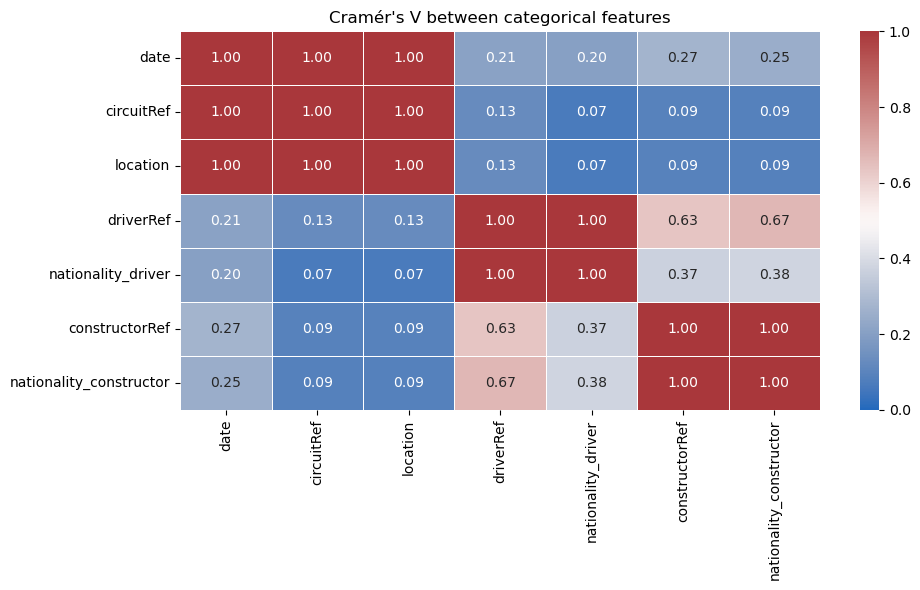

In [79]:
cat_cols = merged.select_dtypes(include=['object', 'category']).columns.tolist()

def cramers_v(x, y):
    """Cramér's V avec correction de biais (Bergsma & Wicher)."""
    cm = pd.crosstab(x, y)
    if cm.size == 0:
        return np.nan
    chi2, p, dof, ex = chi2_contingency(cm, correction=False)
    n = cm.sum().sum()
    if n == 0:
        return np.nan
    phi2 = chi2 / n
    r, k = cm.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denom = min(kcorr-1, rcorr-1)
    if denom <= 0:
        return np.nan
    return np.sqrt(phi2corr / denom)

cramer_mat = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for i, c1 in enumerate(cat_cols):
    for j, c2 in enumerate(cat_cols):
        if j < i:
            cramer_mat.at[c1, c2] = cramer_mat.at[c2, c1]
            continue
        v = cramers_v(merged[c1].fillna('NA'), merged[c2].fillna('NA'))
        cramer_mat.at[c1, c2] = v
        cramer_mat.at[c2, c1] = v

plt.figure(figsize=(10, max(6, 0.4 * len(cat_cols))))
sns.heatmap(cramer_mat.astype(float), annot=True, fmt='.2f', cmap='vlag', vmin=0, vmax=1, linewidths=.5)
plt.title("Cramér's V between categorical features")
plt.tight_layout()
plt.show()

In the Cramer matrix, we can observe redundant variables: 

- 'date', 'circuitRef' and 'location'. It makes sense because for a specific date you will have a specific 'circuitRef'. The 'location' is the city of the circuit so for the same reason, on a ceratin date all races are at the same location.  
- 'driverRef' and 'nationality_driver'. The nationality of the driver is unrelevant to our analysis and no driver changed nationality.  
- 'constructorRef' and 'nationality_constructor', same as for the driver informations.

So we see that all those maximum correlations are logical and are redundant informations that could mislead our model into making overfitting.

We can also observe the strong correlation (0.63) between 'driverRef' and 'constructorRef' highlighting the fact that most drivers keep the same constructor during their F1 journey but some changed.

# Pre-processing

Now that we have observed our data, we can apply bigger changes to our merged dataset. Some changes can be applied before and some after the train/test split to avoid data leakage.

We already did some minor changes before because I thought it was more interesting to do them before the generation of our matrix.

First we will rename some columns to keep the same convention:

In [80]:
merged = merged.rename(columns={'lap': 'currentLap'})
merged = merged.rename(columns={'laps': 'totalLaps'})
merged= merged.rename(columns={'length (km)': 'trackLength'})
merged= merged.rename(columns={'Turns ': 'trackTurns'})
merged= merged.rename(columns={'nationality_driver': 'driverNationality'})
merged= merged.rename(columns={'nationality_constructor': 'constructorNationality'})
cleaned=merged.copy(deep=True)

In [81]:
print(cleaned.columns.tolist())

['raceId', 'driverId', 'currentLap', 'constructorId', 'grid', 'position', 'points', 'totalLaps', 'statusId', 'year', 'circuitId', 'date', 'circuitRef', 'location', 'trackLength', 'trackTurns', 'driverRef', 'driverNationality', 'constructorRef', 'constructorNationality', 'lapSeconds', 'fastestLapTime']


In order to avoid data leakage, we have to delete columns that give information that we obtain after the race. 

In [55]:
cols_future_info = ['position', 'points', 'statusId', 'totalLaps', 'currentLap', 'lapSeconds']
cleaned.drop(columns=cols_future_info, inplace=True)
print("Dropped columns:", cols_future_info)
print("Remaining columns:", cleaned.columns.tolist())

Dropped columns: ['position', 'points', 'statusId', 'totalLaps', 'currentLap', 'lapSeconds']
Remaining columns: ['raceId', 'driverId', 'constructorId', 'grid', 'year', 'circuitId', 'date', 'circuitRef', 'location', 'trackLength', 'trackTurns', 'driverRef', 'driverNationality', 'constructorRef', 'constructorNationality', 'fastestLapTime']


Then, we can also drop redundant columns such as 'year' and 'date', in that case, only 'year' is necessary because 'date' generate more overfitting and its format is harder to exploit.

# Formalisation of the problem

1. Objective

The goal is to predict the fastest lap time (in seconds) of each driver in each race using historical Formula 1 race data (1996–2020).
This prediction can help analyze performance trends of drivers, constructors, and circuits and predict future performances.

2. Type of Problem

Regression problem (target variable is continuous).

Supervised learning, since we have labeled data (past fastest lap times).

3. Target Variable

fastest_lap_time (continuous) → the fastest lap time per driver in a given race, expressed in seconds.

Computed from milliseconds as the minimum lap time (min(milliseconds/1000)) for each (driverId, raceId).
